In [2]:
# init
import importlib, sys

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

from tqdm import tqdm

Textwidth: float = 4.25279  # in
Textheight: float = 6.85173  # in

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic("config", "InlineBackend.rc = {'figure.dpi': 300}")

# Single IV

In [81]:
# load data
data = np.load("single_iv/fit.npz")

GN_G0 = data["GN_G0"]
T_K = data["T_K"]
Delta_meV = data["Delta_meV"]
gamma_meV = data["gamma_meV"]
sigmaV_mV = data["sigmaV_mV"]

V_mV = data["V_mV"]
Iexp_nA = data["Iexp_nA"]
Ifit_nA = data["Ifit_nA"]
dGexp_G0 = np.gradient(Iexp_nA, V_mV) / sc.G0_muS
dGfit_G0 = np.gradient(Ifit_nA, V_mV) / sc.G0_muS
dRexp_R0 = np.gradient(V_mV, Iexp_nA) * sc.G0_muS
dRfit_R0 = np.gradient(V_mV, Ifit_nA) * sc.G0_muS

Vbins_mV = np.linspace(-0.05, 0.55, 601)
Ibins_nA = np.linspace(0, 8, 401)

dRexp_R0 = sc.bin_y_over_x(dRexp_R0, Iexp_nA, Ibins_nA)
dRfit_R0 = sc.bin_y_over_x(dRfit_R0, Ifit_nA, Ibins_nA)
dGexp_G0 = sc.bin_y_over_x(dGexp_G0, V_mV, Vbins_mV)
dGfit_G0 = sc.bin_y_over_x(dGfit_G0, V_mV, Vbins_mV)
Iexp_nA = sc.bin_y_over_x(Iexp_nA, V_mV, Vbins_mV)
Ifit_nA = sc.bin_y_over_x(Ifit_nA, V_mV, Vbins_mV)
V_mV = Vbins_mV

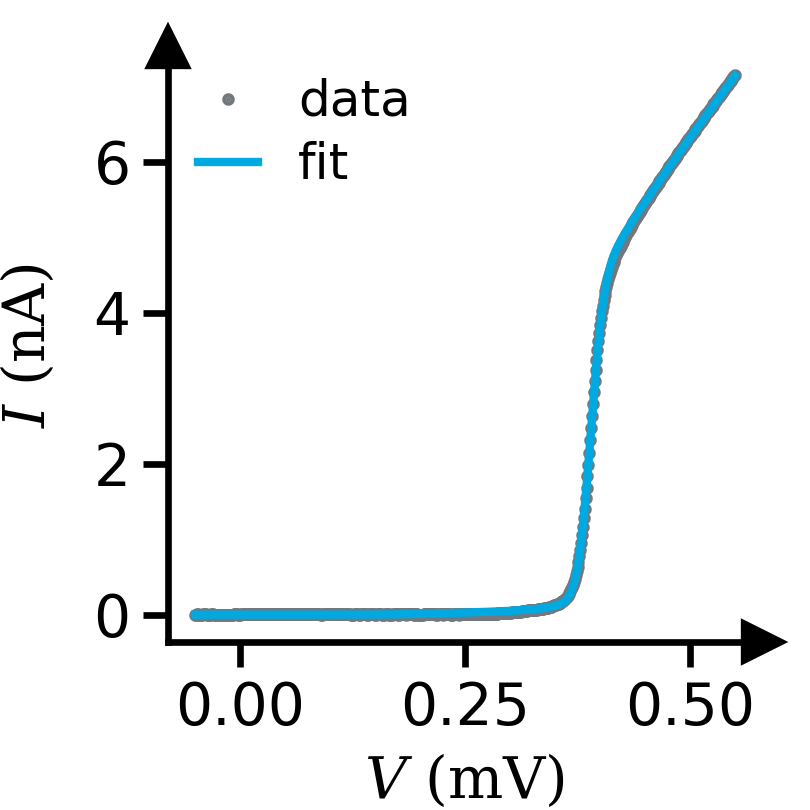

In [82]:
# plot data
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.2, 0.2))

ax.plot(
    Vbins_mV,
    Iexp_nA,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    Ifit_nA,
    label="fit",
    color=sc.seeblau100,
)


ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"
title = "tunnelbarrier/highres/single_iv/fit-iv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

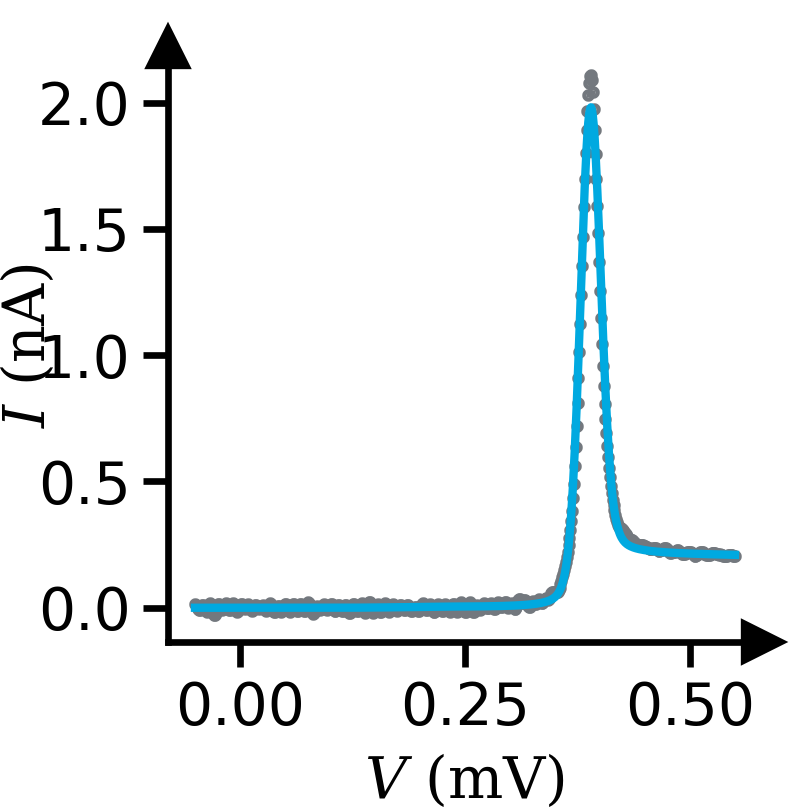

In [83]:
# plot data
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.2, 0.2))

ax.plot(
    Vbins_mV,
    dGexp_G0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Vbins_mV,
    dGfit_G0,
    label="fit",
    color=sc.seeblau100,
)

xlabel = "$V\\ \\mathrm{(mV)}$"
ylabel = "$I\\ \\mathrm{(nA)}$"
title = "tunnelbarrier/highres/single_iv/fit-didv"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

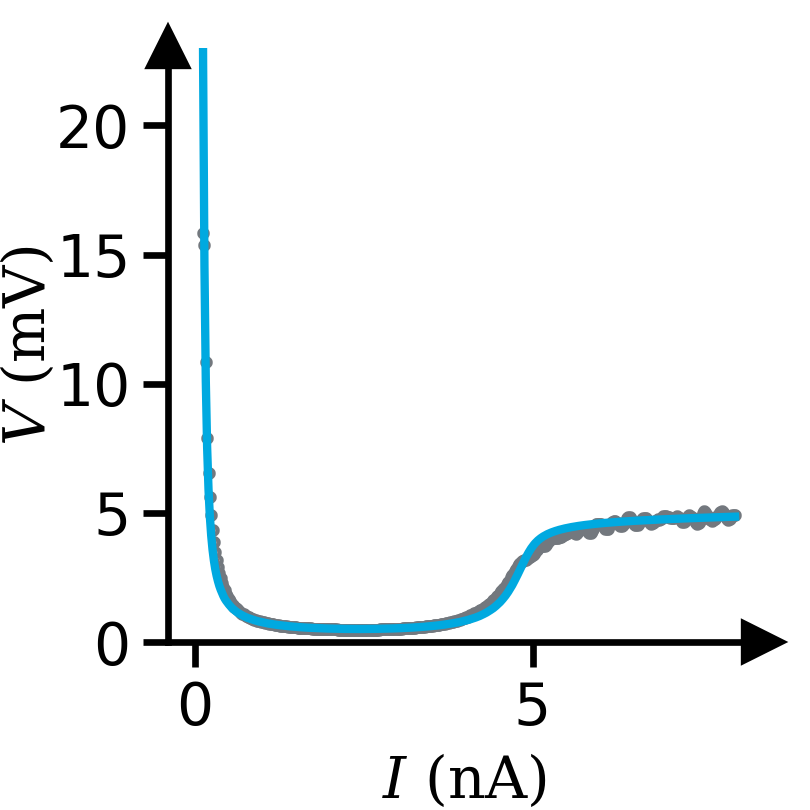

In [84]:
# plot data
fig, ax = sc.get_figure(figsize=(1.35, 1.35), padding=(0.2, 0.2))

ax.plot(
    Ibins_nA,
    dRexp_R0,
    ".",
    label="data",
    color=sc.seegrau100,
)
ax.plot(
    Ibins_nA,
    dRfit_R0,
    label="data",
    color=sc.seeblau100,
)

ax.set_ylim(0, 23)

ylabel = "$V\\ \\mathrm{(mV)}$"
xlabel = "$I\\ \\mathrm{(nA)}$"
title = "tunnelbarrier/highres/single_iv/fit-dvdi"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

# Amplitude Study @ 18.3 GHz (raw)

In [50]:
# load data
data = np.load("amp_18.3GHz/eva.npz")

Vbias_mV = data["Vbias_mV"]
Ibias_nA = data["Ibias_nA"]
Aout_mV = data["Aout_mV"]
dGexp_G0 = data["dGexp_G0"]
dRexp_R0 = data["dRexp_R0"]
Iexp_nA = data["Iexp_nA"]
nu_GHz = data["nu_GHz"]

In [ ]:
# restoring dimensions
eta = 0.002173  # (3)
GN_G0: float = 0.18877592218372993
Delta_meV: float = 0.19345000789195935

Aintrest_mV = [
    0.0,
    98.86444286728177,
    190.27679205110007,
    271.7530163236338,
    378.06955287437904,
]

Vbiaslim = (-0.5 * Delta_meV, 4.5 * Delta_meV)
Abiaslim = (0.0, 458.5521646557843)
Ibiaslim = (
    -0.5 * (GN_G0 * sc.G0_muS * Delta_meV),
    4.5 * (GN_G0 * sc.G0_muS * Delta_meV),
)
Ilim = (-0.05 * (GN_G0 * sc.G0_muS * Delta_meV), 4.5 * (GN_G0 * sc.G0_muS * Delta_meV))
dGlim = (-0.05 * GN_G0, 4.5 * GN_G0)
dRlim = (-0.05 / GN_G0, 4.5 / GN_G0)

Vlabel = "$V\\,\\mathrm{(mV)}$"
Alabel = "$A_\\mathrm{out}\\,\\mathrm{(mV)}$"
Ilabel = "$I\\,\\mathrm{(nA)}$"
dGlabel = r"$\mathrm{d}I/\mathrm{d}V\,/\,G_\mathrm{0}$"
dRlabel = r"$\mathrm{d}V/\mathrm{d}I\,\cdot\,G_\mathrm{0}$"

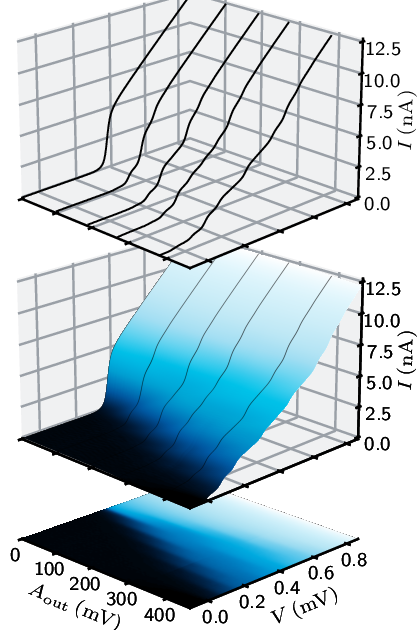

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/raw_iv/main.png

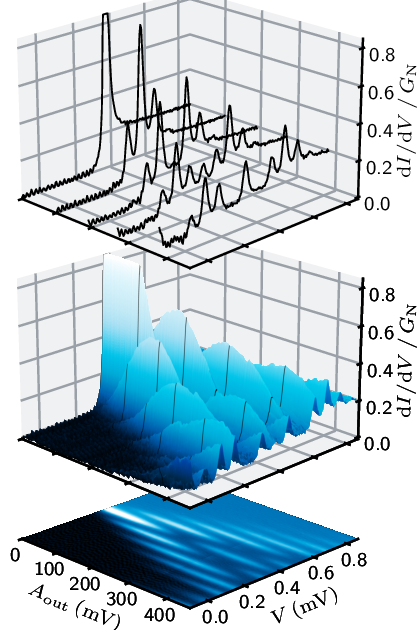

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/raw_didv/main.png

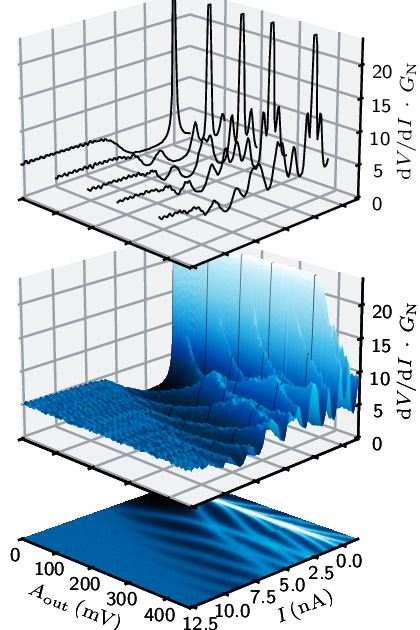

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/raw_dvdi/main.png

In [52]:
# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias_mV,
    Abias=Aout_mV,
    Ibias=Ibias_nA,
    Iexp=Iexp_nA,
    dGexp=dGexp_G0,
    dRexp=dRexp_R0,
    waterfall_traces=Aintrest_mV,
    Vbiaslim=Vbiaslim,
    Abiaslim=Abiaslim,
    Ibiaslim=Ibiaslim,
    Ilim=Ilim,
    dGlim=dGlim,
    dRlim=dRlim,
    Vbiasticks=None,
    Abiasticks=None,
    Ibiasticks=None,
    Iticks=None,
    dGticks=None,
    dRticks=None,
    Vlabel=Vlabel,
    Alabel=Alabel,
    Ilabel=Ilabel,
    dGlabel=dGlabel,
    dRlabel=dRlabel,
    name="raw",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz/",
)

# Amplitude Study @ 18.3 GHz (cal)

In [82]:
# load data
data = np.load("amp_18.3GHz/cal.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Abias = data["Abias"]
dGexp = data["dGexp"]
dRexp = data["dRexp"]
Iexp = data["Iexp"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

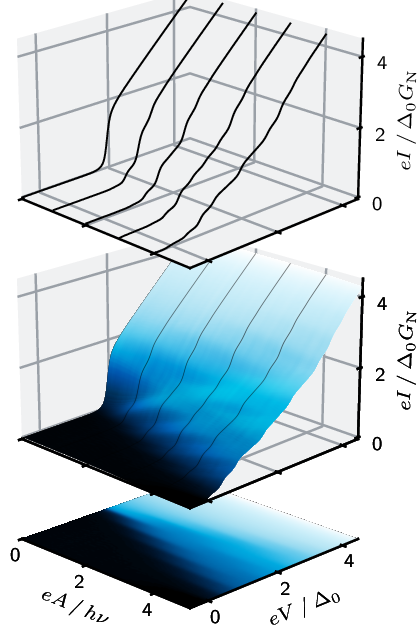

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/cal_iv/main.png

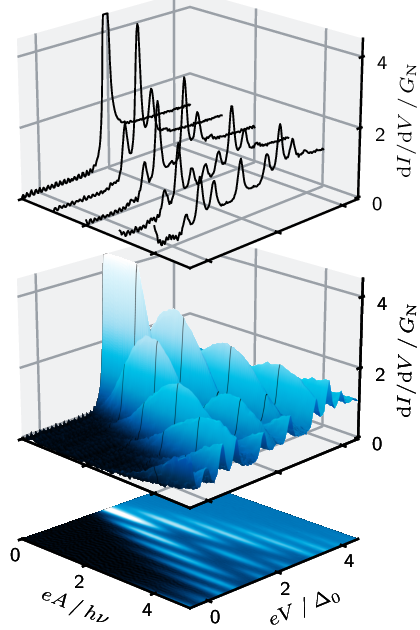

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/cal_didv/main.png

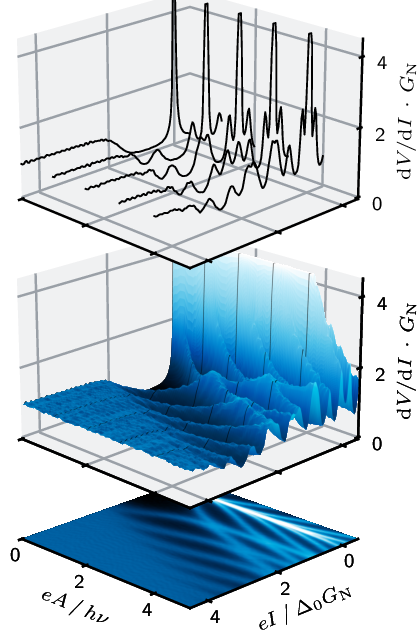

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/cal_dvdi/main.png

In [83]:
# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0.0, 1.0, 2.0, 3.0, 4.0],
    name="cal",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz",
)

# Amplitude Study @ 18.3 GHz (sim)

In [5]:
# load data
data = np.load("amp_18.3GHz/sim.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Abias = data["Abias"]
Isim = data["Isim"]
dGsim = data["dGsim"]
dRsim = data["dRsim"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

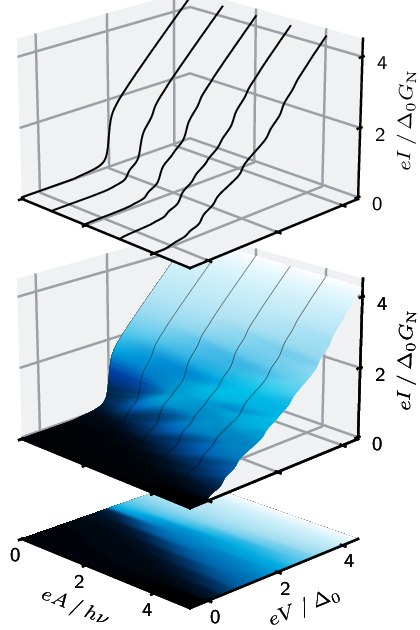

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/sim_iv/main.png

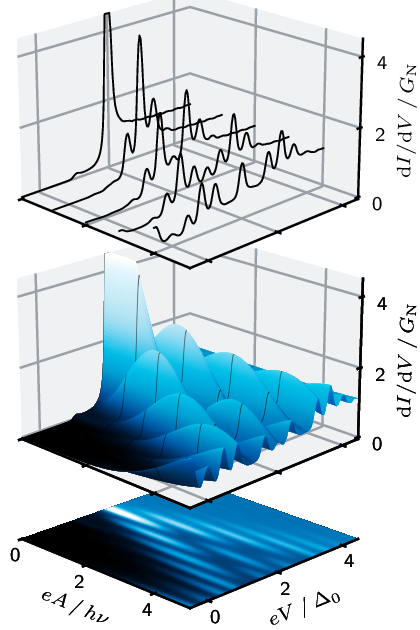

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/sim_didv/main.png

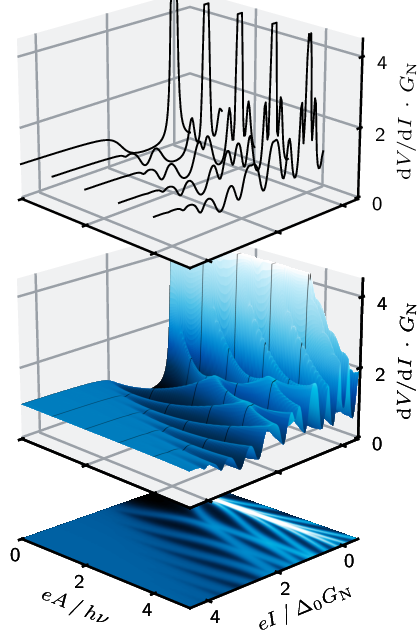

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/amp_18.3GHz/sim_dvdi/main.png

In [6]:
# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Abias,
    Ibias=Ibias,
    Iexp=Isim,
    dGexp=dGsim,
    dRexp=dRsim,
    waterfall_traces=[0.0, 1.0, 2.0, 3.0, 4.0],
    name="sim",
    sub_dir="tunnelbarrier/highres/amp_18.3GHz",
)

# Amplitude Study @ 18.3 GHz (fit)

In [59]:
# load data
data = np.load("amp_18.3GHz/fit.npz")

Aout_mV = data["Aout_mV"]
Afit_mV = data["Afit_mV"]
uAfit_mV = data["uAfit_mV"]
Tfit_K = data["Tfit_K"]
uTfit_K = data["uTfit_K"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

In [60]:
figsize = (1.4, 1.2)
fig, ax = sc.get_figure(
    figsize=figsize,
    padding=(0.18, 0.2),
)

ax.plot(
    Aout_mV * 1e-3,
    Afit_mV / (nu_GHz * sc.h_pVs),
)

xlabel = "$A_\\mathrm{out}\\ \\mathrm{(mV)}$"
ylabel = "$eA\\,/\\,h\\nu$"
title = "tunnelbarrier/highres/amp_18.3GHz/fit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# Amplitude Study @ 13.6 GHz (fit)

In [65]:
# load data
data = np.load("amp_13.6GHz/fit.npz")

Aout_mV = data["Aout_mV"]
Afit_mV = data["Afit_mV"]
uAfit_mV = data["uAfit_mV"]
Tfit_K = data["Tfit_K"]
uTfit_K = data["uTfit_K"]
nu_GHz = data["nu_GHz"]
GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

In [72]:
# plot data
fig, ax = sc.get_figure(
    figsize=(1.4, 1.2),
    padding=(0.18, 0.2),
)

ax.plot(
    Aout_mV * 1e-3,
    Afit_mV / (nu_GHz * sc.h_pVs),
)

xlabel = "$A_\\mathrm{out}\\ \\mathrm{(mV)}$"
ylabel = "$eA\\,/\\,h\\nu$"
title = "tunnelbarrier/highres/amp_13.6GHz/fit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)

# Temperature Study (cal)

In [25]:
# load data
data = np.load("temperature/cal.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Tcal = data["Tcal"]
dGexp = data["dGexp"]
dRexp = data["dRexp"]
Iexp = data["Iexp"]

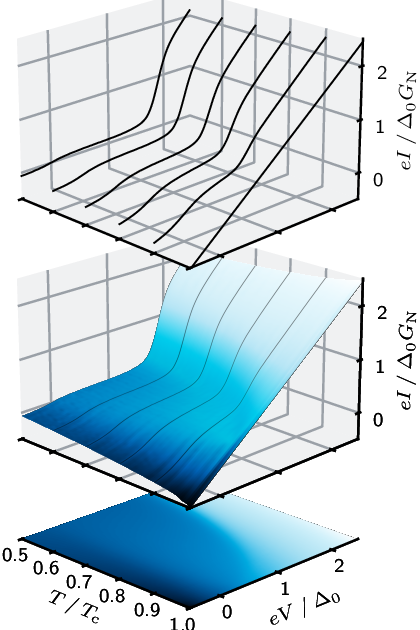

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/temperature/cal_iv/main.png

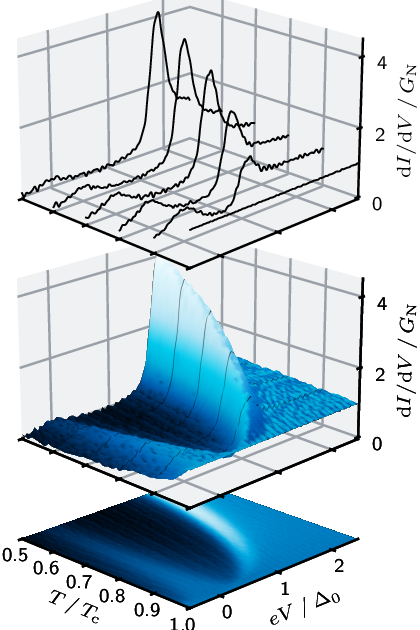

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/temperature/cal_didv/main.png

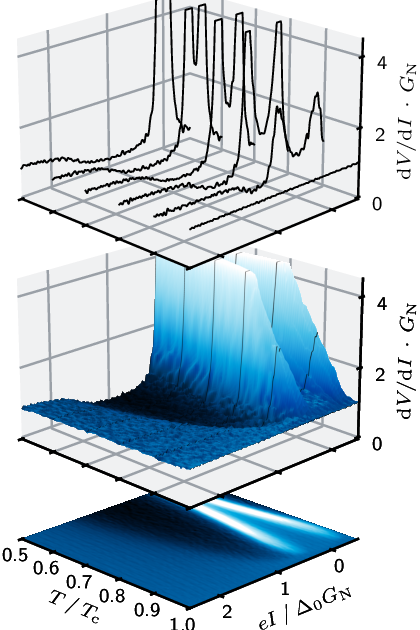

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/temperature/cal_dvdi/main.png

In [26]:
# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Tcal,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    Abiaslim=(0.5, 1.0),
    Abiasticks=None,
    Vbiaslim=(-0.5, 2.5),
    Vbiasticks=[0, 1, 2],
    Ibiaslim=(-0.5, 2.5),
    Ibiasticks=[0, 1, 2],
    Ilim=(-0.5, 2.5),
    Iticks=[0, 1, 2],
    # dRlim=(-0.05, 5),
    # dRticks=None,
    # dGlim=(-0.05, 5),
    # dGticks=None,
    Alabel="$T\\,/\\,T_\\mathrm{c}$",
    name="cal",
    sub_dir="tunnelbarrier/highres/temperature",
)

# Temperature Study (Sim)

In [22]:
# load data
data = np.load("temperature/sim.npz")

Vbias = data["Vbias"]
Ibias = data["Ibias"]
Tcal = data["Tsim"]
dGexp = data["dGsim"]
dRexp = data["dRsim"]
Iexp = data["Isim"]

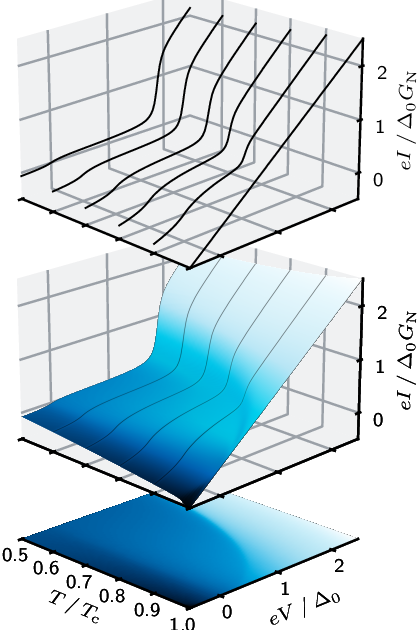

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/temperature/sim_iv/main.png

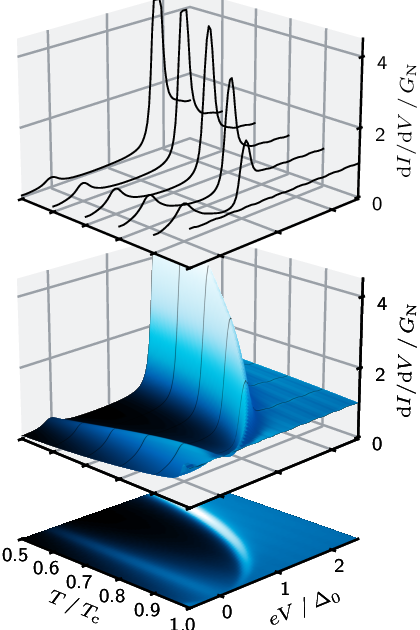

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/temperature/sim_didv/main.png

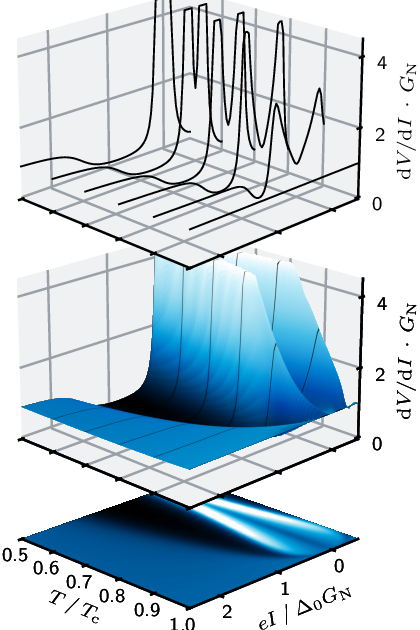

/Users/oliver/Documents/cryolab/superconductivity/thesis/tunnelbarrier/highres/temperature/sim_dvdi/main.png

In [23]:
# export the composite plots
from superconductivity.visuals.thesis.latex import export_amplitude_maps_thesis

exports = export_amplitude_maps_thesis(
    Vbias=Vbias,
    Abias=Tcal,
    Ibias=Ibias,
    Iexp=Iexp,
    dGexp=dGexp,
    dRexp=dRexp,
    waterfall_traces=[0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    Abiaslim=(0.5, 1.0),
    Abiasticks=None,
    Vbiaslim=(-0.5, 2.5),
    Vbiasticks=[0, 1, 2],
    Ibiaslim=(-0.5, 2.5),
    Ibiasticks=[0, 1, 2],
    Ilim=(-0.5, 2.5),
    Iticks=[0, 1, 2],
    # dRlim=(-0.05, 5),
    # dRticks=None,
    # dGlim=(-0.05, 5),
    # dGticks=None,
    Alabel="$T\\,/\\,T_\\mathrm{c}$",
    name="sim",
    sub_dir="tunnelbarrier/highres/temperature",
)

# Temperature Study (fit)

In [14]:
# load data
data = np.load("temperature/eva.npz")
Pheater_uW = data["Pheater_uW"]


data = np.load("temperature/fit.npz")

GN_G0 = data["GN_G0"]
Delta_meV = data["Delta_meV"]

Tbath_K = data["Tbath_K"]
Tfit_K = data["Tfit_K"]
uTfit_K = data["uTfit_K"]

Tcritical_K = data["Tcritical_K"]
uTcritical_K = data["uTcritical_K"]
Tbase_K = data["Tbase_K"]
uTbase_K = data["uTbase_K"]
Toff_K = data["Toff_K"]
uToff_K = data["uToff_K"]
alphaT = data["alphaT"]
ualphaT = data["ualphaT"]

mask0 = data["mask0"]
mask1 = data["mask1"]

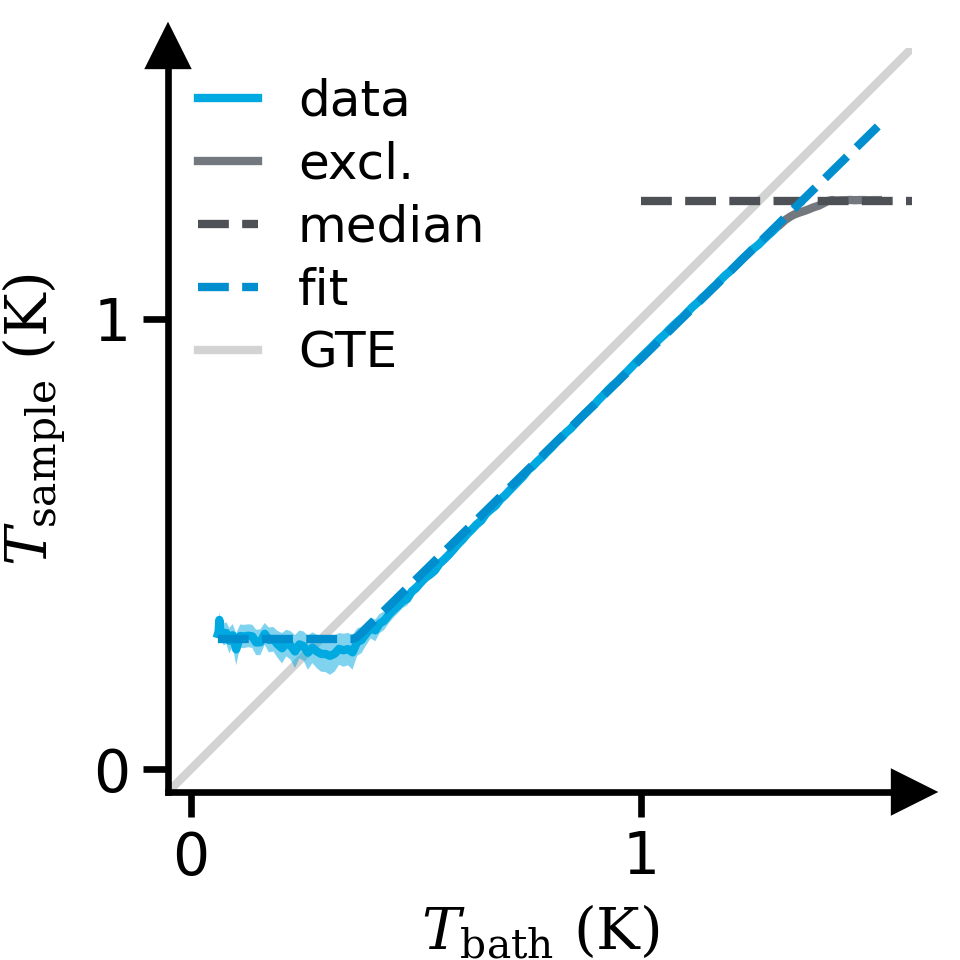

In [ ]:
# plot data
fig, ax = sc.get_figure(figsize=(1.6, 1.6), padding=(0.2, 0.2))

xlim = [-0.05, 1.6]
ylim = xlim

# data
ax.plot(
    Tbath_K[mask0],
    Tfit_K[mask0],
    "-",
    color=sc.seeblau100,
    label="data",
    zorder=0,
)
ax.fill_between(
    Tbath_K[mask0],
    +Tfit_K[mask0] - 2 * uTfit_K[mask0],
    +Tfit_K[mask0] + 2 * uTfit_K[mask0],
    color=sc.seeblau100,
    alpha=0.5,
    edgecolor=None,
    zorder=-1,
)


# fit
def calibration_T(T: NDArray64, T_base: float, T_off: float, alpha: float):
    T = T_off + alpha * T
    return np.where(T <= T_base, T_base, T)


ax.plot(
    [1.0, xlim[1]],
    [Tcritical_K, Tcritical_K],
    "--",
    color=sc.seegrau120,
    label="median",
    zorder=2,
)
ax.plot(
    Tbath_K[mask1],
    Tfit_K[mask1],
    "-",
    color=sc.seegrau100,
    label="excl.",
    zorder=0,
)
ax.fill_between(
    Tbath_K[mask1],
    +Tfit_K[mask1] - uTfit_K[mask1],
    +Tfit_K[mask1] + uTfit_K[mask1],
    color=sc.seegrau100,
    alpha=0.5,
    edgecolor=None,
    zorder=-1,
)


ax.plot(
    Tbath_K,
    calibration_T(Tbath_K, Tbase_K, Toff_K, alphaT),
    "--",
    color=sc.seeblau120,
    label="fit",
    zorder=2,
)

# n = 100_000
# rand0 = np.random.normal(popt[0], perr[0], n)
# rand1 = np.random.normal(popt[1], perr[1], n)
# rand2 = np.random.normal(popt[2], perr[2], n)
# curves = np.array(
#     [calibration_T(Tbath_K, a, b, c) for a, b, c in zip(rand0, rand1, rand2)]
# )
# y_best = calibration_T(Tbath_K, *popt)
# lo, hi = np.percentile(curves, [16, 84], axis=0)  # ~1 sigma band
# ax.fill_between(
#     Tbath_K,
#     lo,
#     hi,
#     color=[*sc.seegrau65, 0.5],
#     edgecolor=None,
# )

# guide to the eye
ax.plot(
    xlim,
    xlim,
    "-",
    color="lightgrey",
    zorder=-10,
    label="GTE",
)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.legend(
    # title="$\\alpha_q = $",
    handlelength=1.2,
    loc="upper left",
    frameon=False,
    fontsize=6,
    title_fontsize=6,
    ncols=1,
    columnspacing=0.8,
    borderpad=0.1,  # reduces padding inside the legend box
    labelspacing=0.3,  # reduces vertical spacing between items
    handletextpad=0.8,  # reduces spacing between line and label
    # bbox_to_anchor=(1.1, 1.1),
)

xlabel = "$T_\\mathrm{bath}\\ \\mathrm{(K)}$"
ylabel = "$T_\\mathrm{sample}\\ \\mathrm{(K)}$"
title = "tunnelbarrier/highres/temperature/fit"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
plt.show()

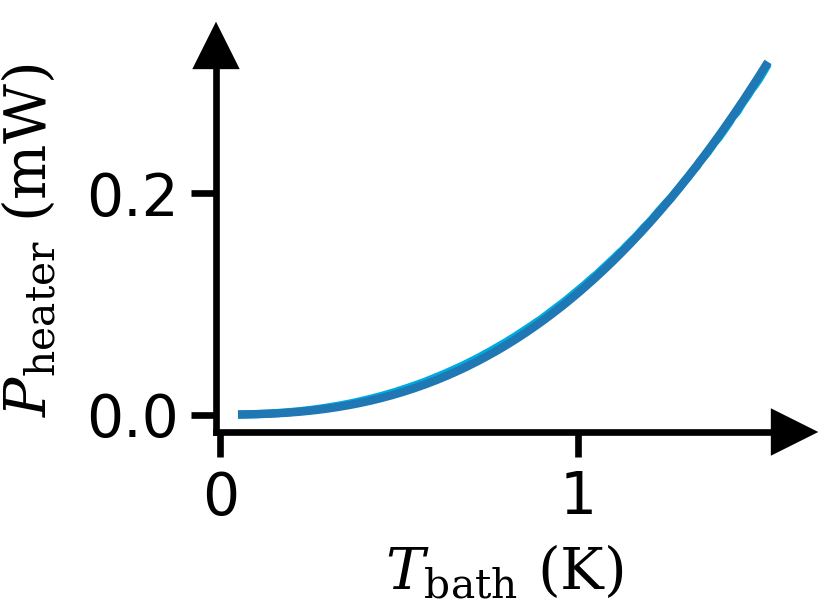

In [41]:
fig, ax = sc.get_figure(figsize=(1.4, 1.0), padding=(0.28, 0.2))

ax.plot(Tbath_K, Pheater_uW * 1e-3, color=sc.seeblau100)
ax.plot(Tbath_K, 0.11 * Tbath_K**2.5)

xlabel = "$T_\\mathrm{bath}\\ \\mathrm{(K)}$"
ylabel = "$P_\\mathrm{heater}\\ \\mathrm{(mW)}$"
title = "tunnelbarrier/highres/temperature/heater"

sc.theory_layout(fig, ax, title, xlabel, ylabel)